In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [20]:
titanic = sns.load_dataset("titanic")

In [21]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [23]:
# HANDLE MISSING DATA - 

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])


imp_median = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_median.fit_transform(titanic[["embarked"]])

In [24]:
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [26]:
X = titanic[features]
y = titanic["survived"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [28]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [ ]:
#DECISION TREE-

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training Accuracy Score", accuracy_score(y_train, y_pred_train) * 100, "%")
print("Training Accuracy Score", accuracy_score(y_test, y_pred_test) * 100, "%")

# This is classical case of OVERFITTING because here data is trained on the training data but not in the testing.

Training Accuracy Score 97.91332263242376 %
Training Accuracy Score 75.3731343283582 %


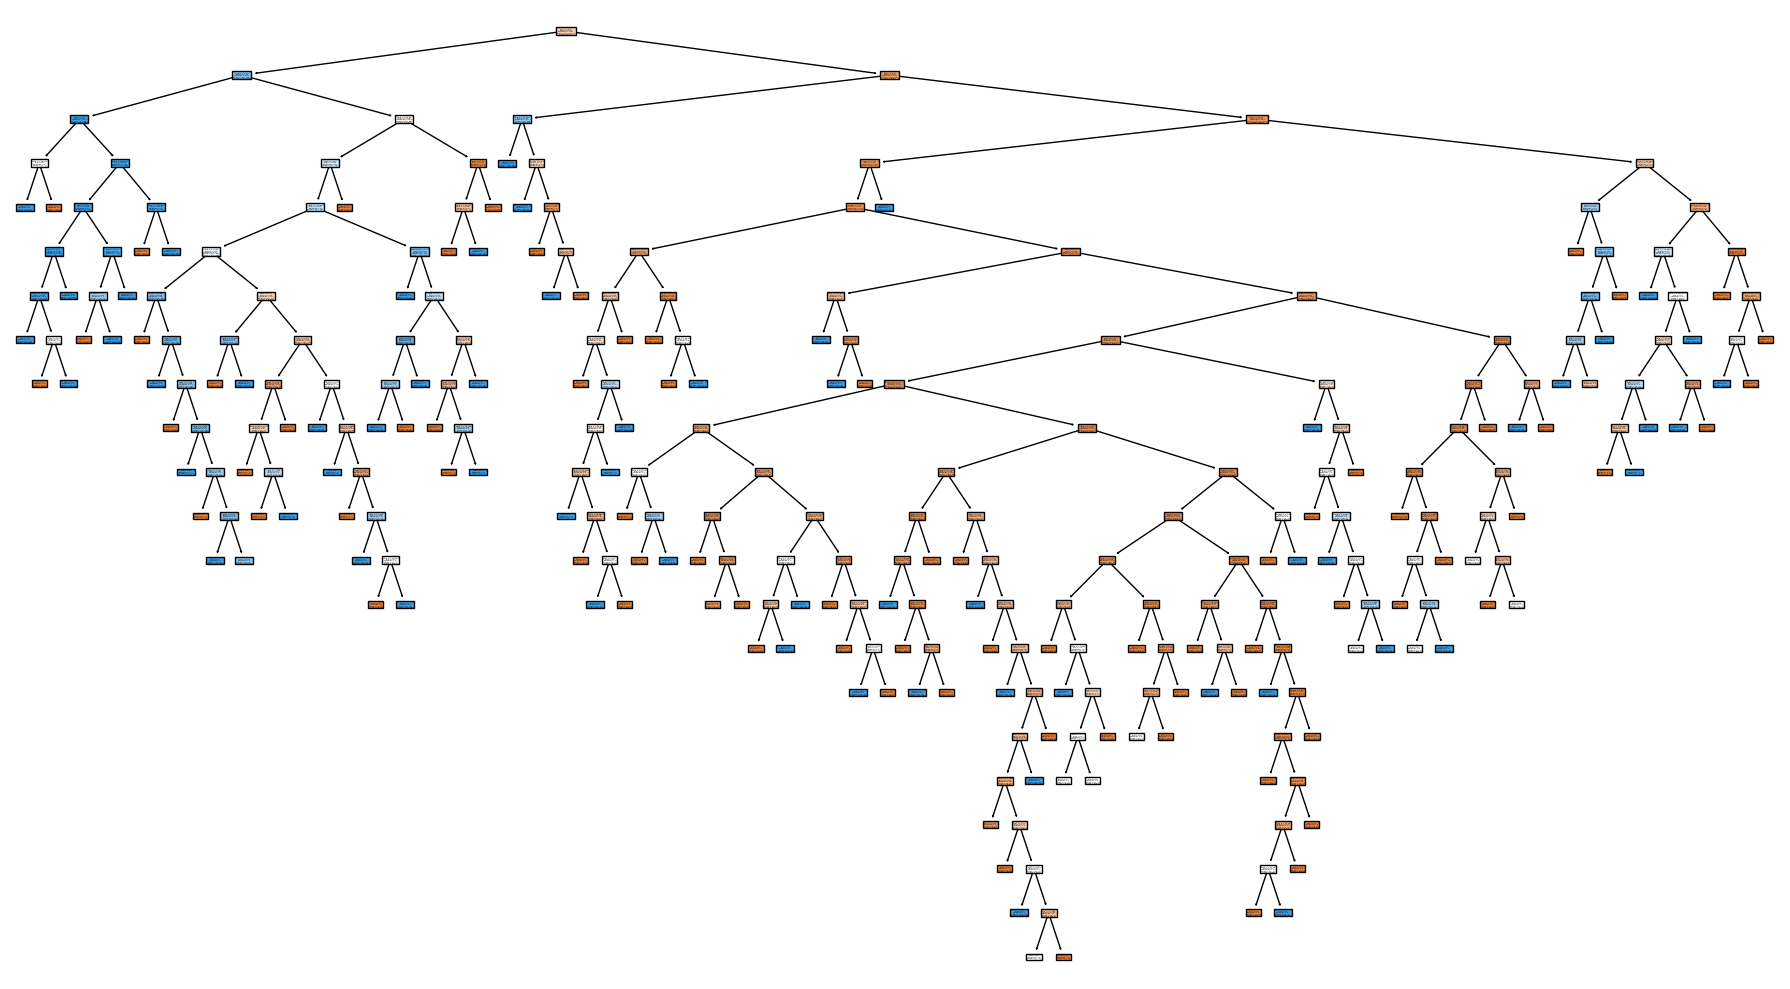

In [30]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

## Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=201,
    oob_score=True
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB Score: ", rf.oob_score_ * 100, "%")
print("Testing Accuracy: ", accuracy_score(y_test, y_pred) * 100, "%")


OOB Score:  80.41733547351525 %
Testing Accuracy:  77.61194029850746 %


In [36]:
#DECISION TREE-

model = DecisionTreeClassifier(max_depth=4)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training Accuracy Score", accuracy_score(y_train, y_pred_train) * 100, "%")
print("Training Accuracy Score", accuracy_score(y_test, y_pred_test) * 100, "%")

# This is classical case of OVERFITTING because here data is trained on the training data but not in the testing.

Training Accuracy Score 84.75120385232745 %
Training Accuracy Score 82.46268656716418 %


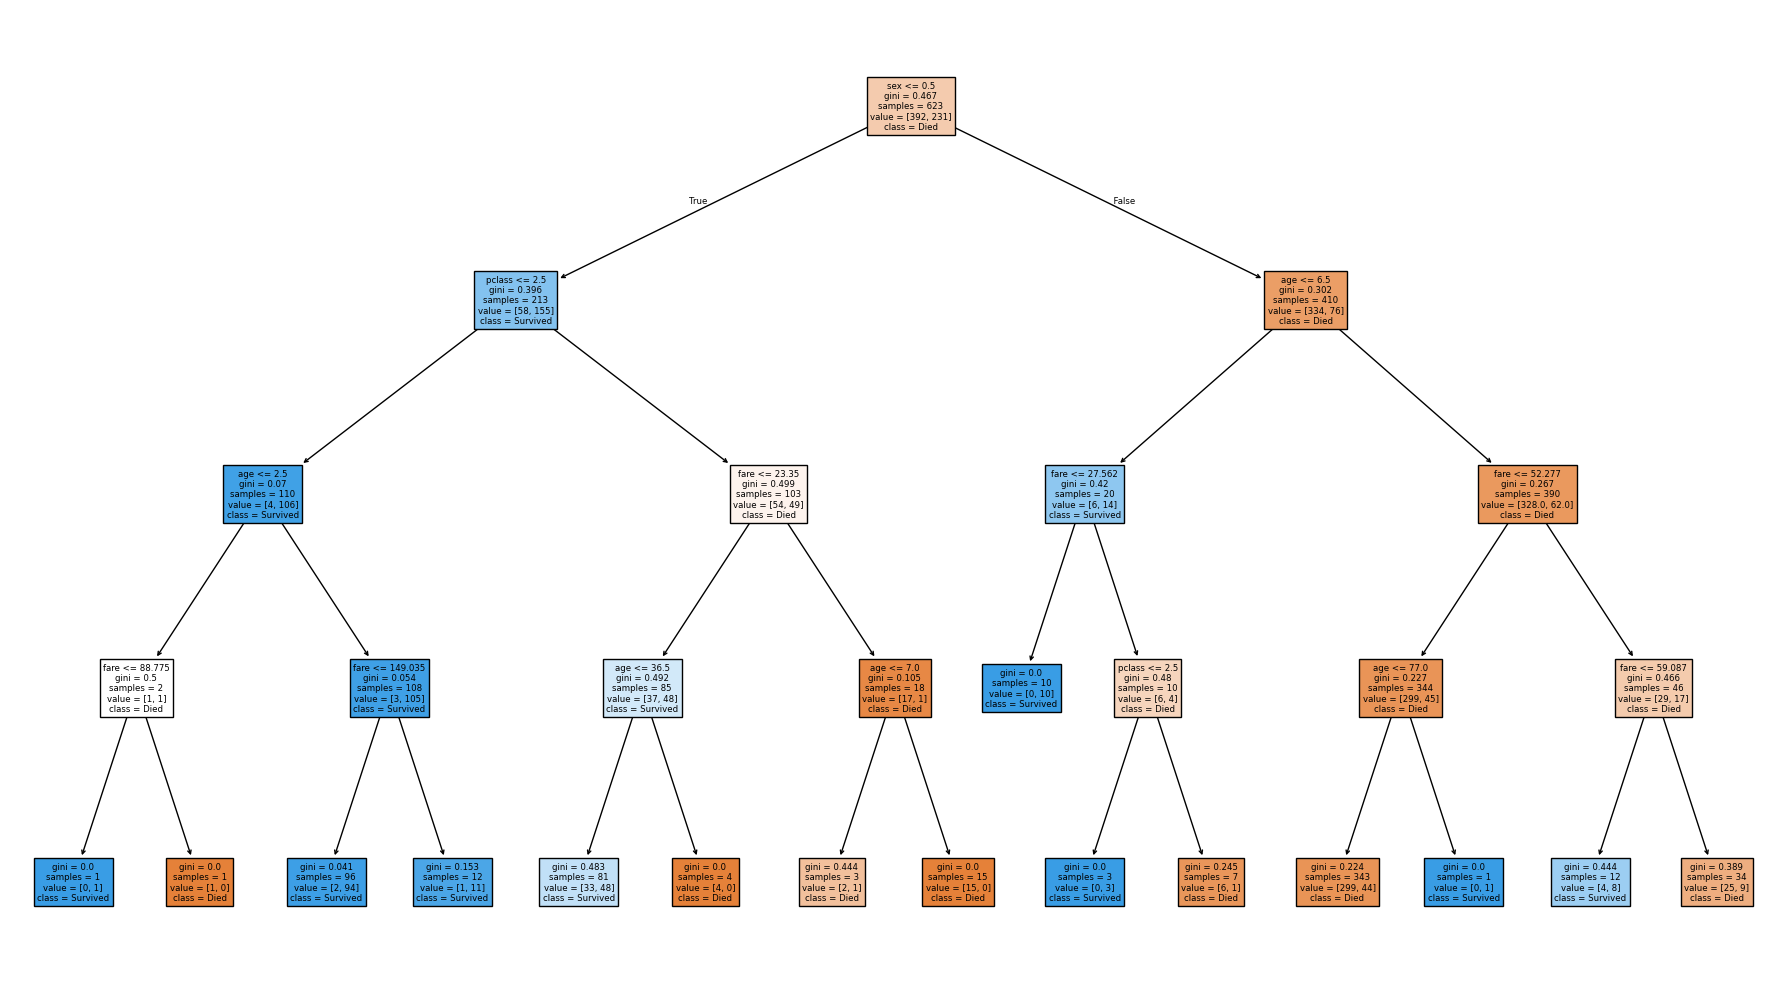

In [37]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=201,
    oob_score=True,
    max_depth=4
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB Score: ", rf.oob_score_ * 100, "%")
print("Testing Accuracy: ", accuracy_score(y_test, y_pred) * 100, "%")


OOB Score:  81.38041733547352 %
Testing Accuracy:  82.46268656716418 %


# Bagging Classifier

In [39]:
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.7723880597014925


In [40]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import BaggingClassifier

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.7947761194029851
